In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# !pip uninstall lightgbm

In [2]:
# 1) 데이터 불러오기
df = pd.read_csv("yeouido_cafe_startup_sample.csv")  # 경로만 환경에 맞게 수정

# 2) X, y 분리
X = df.drop("창업추천", axis=1)
y = df["창업추천"]   # 0=비추천, 1=추천

# 3) Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
X

,역세권_거리_m,오피스_밀도_지수,주거_밀도_지수,평균_소득_백만원,경쟁_카페_수_500m,유동인구_지수,주말_유동인구_지수,임대료_만원,층수_노출_점수,프랜차이즈_비율
0,136.290925,8.426234,5.639787,10.439080,9,9.358217,4.646726,1280.622065,6.117479,0.013869
1,506.799904,4.347515,2.809365,10.157970,16,4.549404,6.238562,1561.606473,2.099204,0.174298
2,150.043223,9.087835,7.962482,7.652965,30,7.204793,3.454717,962.619696,1.457457,0.078335
3,230.442215,5.569619,2.245936,8.872091,12,6.200097,6.424259,940.472320,2.188340,0.546955
4,295.354292,6.670261,5.128478,6.169565,15,7.439599,3.046848,1398.327922,2.068974,0.275574
...,...,...,...,...,...,...,...,...,...,...
495,410.499966,7.838166,8.529360,6.487020,38,8.629491,8.361826,1854.018687,3.848388,0.071320
496,430.308060,7.063321,8.405690,5.287971,28,4.595142,7.916816,499.572636,8.392173,0.205245
497,271.897293,8.294664,3.202458,3.902385,33,4.775337,5.760054,919.067554,8.177421,0.884816
498,59.778243,5.930159,6.578819,11.846505,6,9.788034,4.639057,1041.394061,9.606397,0.344022


In [4]:
y

0      1
1      0
2      1
3      1
4      1
      ..
495    1
496    1
497    0
498    1
499    0
Name: 창업추천, Length: 500, dtype: int64

In [5]:
# 4) 1층(Base) 모델들
base_models = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )),
    ("svc", make_pipeline(
        StandardScaler(),
        SVC(probability=True, random_state=42)
    ))
]

In [7]:
# 5) 2층(Meta) 모델: 로지스틱 회귀
meta_model = LogisticRegression(max_iter=1000)

In [8]:
# 6) StackingClassifier 구성
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False,
    n_jobs=-1
)

In [9]:
# 7) 학습
stack_clf.fit(X_train, y_train)

# 8) 예측
y_pred = stack_clf.predict(X_test)
y_proba = stack_clf.predict_proba(X_test)[:, 1]  # 클래스 1(창업추천) 확률

/Users/administrator/miniconda3/envs/multimodal_rag/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/administrator/miniconda3/envs/multimodal_rag/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown i

In [10]:
# 9) 성능 출력
print("=== Stacking 분류 모델 (창업추천) ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["비추천(0)", "추천(1)"]))

print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))

=== Stacking 분류 모델 (창업추천) ===
Accuracy : 0.9

[Classification Report]
              precision    recall  f1-score   support

      비추천(0)       0.89      0.93      0.91        55
       추천(1)       0.91      0.87      0.89        45

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100


[Confusion Matrix]
[[51  4]
 [ 6 39]]


In [11]:
df_test = X_test.copy()
df_test["실제"] = y_test.values
df_test["예측"] = y_pred
df_test["추천확률"] = y_proba

In [12]:
# 임대료 기준 구간 나누기
low_thr = df_test["임대료_만원"].quantile(0.3)   # 하위 30%
high_thr = df_test["임대료_만원"].quantile(0.7)  # 상위 30%

mask_low = df_test["임대료_만원"] <= low_thr
mask_high = df_test["임대료_만원"] >= high_thr

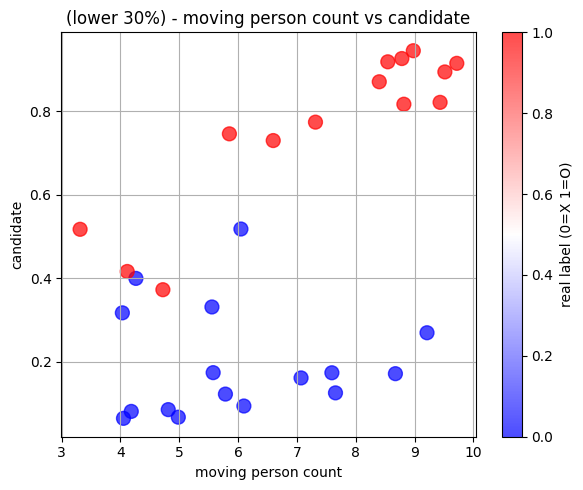

In [ ]:
# 2-1) 저임대 구간
plt.figure(figsize=(6, 5))
plt.scatter(
    df_test.loc[mask_low, "유동인구_지수"], #유동인구_지수
    df_test.loc[mask_low, "추천확률"], #추천확률
    c=df_test.loc[mask_low, "실제"], #실제
    s=100,
    cmap="bwr",
    alpha=0.7
)
plt.colorbar(label="real label (0=X 1=O)") #비추천, 추천
plt.xlabel("moving person count") #유동인구_지수
plt.ylabel("candidate") #추천확률
plt.title("(lower 30%) - moving person count vs candidate") #저임대 구간(하위 30%) - 유동인구 vs 추천확률
plt.grid(True)
plt.tight_layout()
plt.show()

### 저임대 구간도 유동인구가 많을 수록 추천비율이 높음.

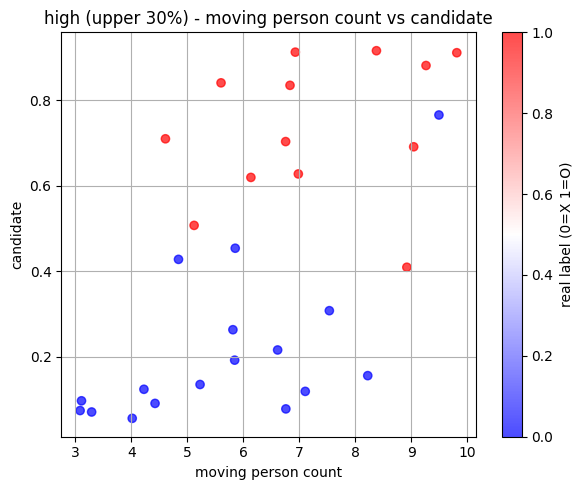

In [ ]:
# 2-2) 고임대 구간
plt.figure(figsize=(6, 5))
plt.scatter(
    df_test.loc[mask_high, "유동인구_지수"],
    df_test.loc[mask_high, "추천확률"],
    c=df_test.loc[mask_high, "실제"],
    cmap="bwr",
    alpha=0.7
)
plt.colorbar(label="real label (0=X 1=O)")
plt.xlabel("moving person count")
plt.ylabel("candidate")
plt.title("high (upper 30%) - moving person count vs candidate")
plt.grid(True)
plt.tight_layout()
plt.show()

### 고임대 구간도 유동인구가 많을 수록 추천비율이 높음.

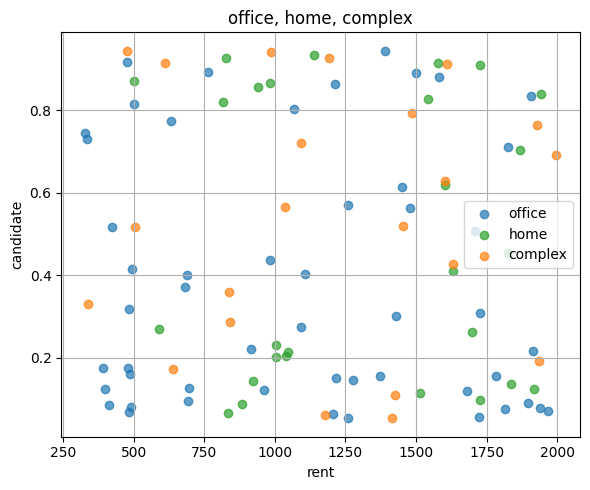

In [26]:
# 상권 타입 만들기
def area_type(row):
    if row["오피스_밀도_지수"] >= row["주거_밀도_지수"] + 1:
        return "office"
    elif row["주거_밀도_지수"] >= row["오피스_밀도_지수"] + 1:
        return "home"
    else:
        return "complex"

df_test["상권타입"] = df_test.apply(area_type, axis=1)

# 색상 매핑
type_colors = {
    "office": "tab:blue",
    "home": "tab:green",
    "complex": "tab:orange"
}

plt.figure(figsize=(6, 5))
for t, color in type_colors.items():
    mask = df_test["상권타입"] == t
    plt.scatter(
        df_test.loc[mask, "임대료_만원"],
        df_test.loc[mask, "추천확률"],
        c=color,
        alpha=0.7,
        label=t
    )

plt.xlabel("rent") #임대료_만원
plt.ylabel("candidate") #추천확률 (클래스1 확률)
plt.title("office, home, complex") #상권 타입별 (오피스/주거/복합) - 임대료 vs 추천확률
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 임대료가 높아져도 세 가지 상권 유형(office, home, complex) 모두에서 추천 확률(candiate) 분포가 넓게 퍼져 있어, 임대료만으로는 창업 적합도를 단정하기 어렵습니다.

# office 타입은 전반적으로 추천 확률이 낮은 구간에도 많이 위치해, 임대료 대비 경쟁이나 수요가 더 민감할 가능성이 보입니다.

# complex(복합형) 상권은 중·고 임대료에서 비교적 고른 추천 확률 분포를 보여, 다양한 조건에서도 창업 가능성이 유지되는 유형으로 해석됩니다.

In [27]:
# 예제 1: “조건 좋음 → 추천일 것 같은 후보” --> “웬만하면 추천” 나올 것 같은 후보

# 역세권_거리_m: 200m (역이 매우 가깝다)

# 오피스_밀도_지수: 9.0 (오피스 많음)

# 주거_밀도_지수: 4.0 (주거는 보통)

# 평균_소득_백만원: 9.0 (소득 수준 높음)

# 경쟁_카페_수_500m: 10개 (경쟁은 있지만 과도하진 않음)

# 유동인구_지수: 9.0 (사람 많이 다님)

# 주말_유동인구_지수: 7.0 (주말도 꽤 붐빔)

# 임대료_만원: 1200 (너무 싸지도 비싸지도 않은 중간)

# 층수_노출_점수: 8.0 (노출 좋음, 1층 코너 느낌)

# 프랜차이즈_비율: 0.3 (프랜차이즈가 어느 정도 있으나 독점은 아님)

In [ ]:
# 예제 2: “조건 안 좋음 → 비추천일 것 같은 후보” --> “웬만하면 비추천” 나올 것 같은 후보.

# 역세권_거리_m: 900m (역에서 멂)

# 오피스_밀도_지수: 4.5 (오피스 적음)

# 주거_밀도_지수: 3.0 (주거도 많지 않음)

# 평균_소득_백만원: 5.0 (소득 보통 이하)

# 경쟁_카페_수_500m: 30개 (경쟁 과도)

# 유동인구_지수: 4.0 (유동인구 적은 편)

# 주말_유동인구_지수: 3.5 (주말도 별로)

# 임대료_만원: 1800 (비싼 임대료)

# 층수_노출_점수: 3.0 (지하/안쪽 매장 느낌)

# 프랜차이즈_비율: 0.8 (프랜 카페 천지)

In [28]:
# -----------------------------
# 4) 테스트용 시나리오 2개 정의
# -----------------------------
scenario_good = {
    "역세권_거리_m": 200,
    "오피스_밀도_지수": 9.0,
    "주거_밀도_지수": 4.0,
    "평균_소득_백만원": 9.0,
    "경쟁_카페_수_500m": 10,
    "유동인구_지수": 9.0,
    "주말_유동인구_지수": 7.0,
    "임대료_만원": 1200,
    "층수_노출_점수": 8.0,
    "프랜차이즈_비율": 0.3
}

In [29]:
scenario_bad = {
    "역세권_거리_m": 900,
    "오피스_밀도_지수": 4.5,
    "주거_밀도_지수": 3.0,
    "평균_소득_백만원": 5.0,
    "경쟁_카페_수_500m": 30,
    "유동인구_지수": 4.0,
    "주말_유동인구_지수": 3.5,
    "임대료_만원": 1800,
    "층수_노출_점수": 3.0,
    "프랜차이즈_비율": 0.8
}

In [30]:
# DataFrame으로 묶기 (컬럼 순서를 X와 맞춰줌)
test_df = pd.DataFrame([scenario_good, scenario_bad])
test_df = test_df[X.columns]  # 안전하게 컬럼 순서 맞추기

In [ ]:
# 결과를 보는 포인트

# 시나리오1(조건 좋음)은

# 추천 확률이 0.6~0.9 사이 정도로 나오는지

# 최종 판단이 추천(1) 인지 확인

# 시나리오2(조건 안 좋음)은

# 추천 확률이 0.1~0.4 정도로 낮게 나오는지

# 최종 판단이 비추천(0) 인지 확인


# -----------------------------
# 5) 시나리오별 추천/비추천 예측
# -----------------------------
proba = stack_clf.predict_proba(test_df)[:, 1]   # 클래스1(추천) 확률
pred  = stack_clf.predict(test_df)               # 0 or 1

scenario_names = ["시나리오1_조건좋음", "시나리오2_조건나쁨"]

for name, p, c in zip(scenario_names, proba, pred):
    print(f"\n[{name}]")
    print(f"추천 확률: {p:.3f}")
    print("최종 판단:", "추천(1)" if c == 1 else "비추천(0)")


[시나리오1_조건좋음]
추천 확률: 0.938
최종 판단: 추천(1)

[시나리오2_조건나쁨]
추천 확률: 0.052
최종 판단: 비추천(0)
